# Матричное умножение 

In [1]:
import matplotlib.pyplot as plt

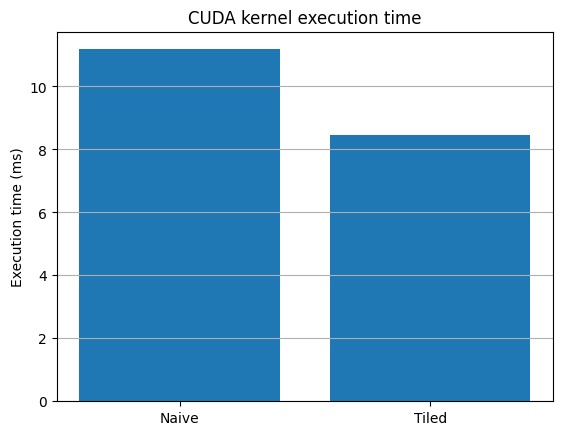

In [ ]:
kernels = ["Naive", "Tiled"]
time_ms = [11.18, 8.45]

plt.figure()
plt.bar(kernels, time_ms)
plt.ylabel("Execution time (ms)")
plt.title("CUDA kernel execution time")
plt.grid(axis="y")
plt.show()

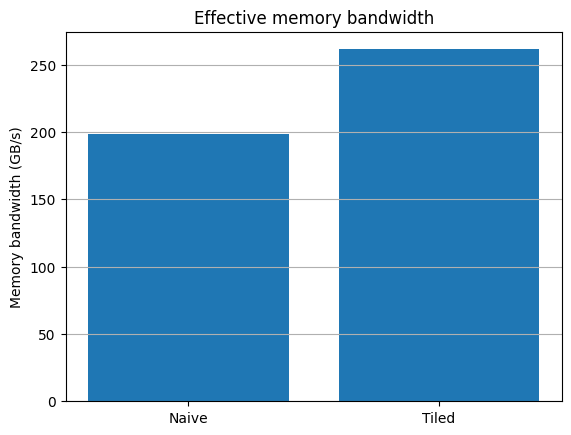

In [2]:
memory_bw = [198.79, 261.43]  # GB/s

plt.figure()
plt.bar(kernels, memory_bw)
plt.ylabel("Memory bandwidth (GB/s)")
plt.title("Effective memory bandwidth")
plt.grid(axis="y")
plt.show()


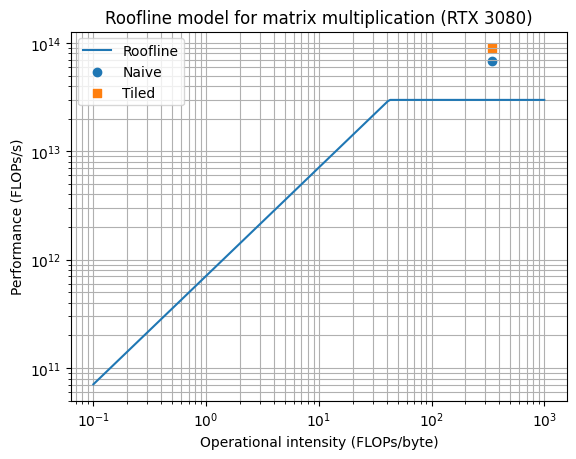

In [ ]:
import numpy as np

# Теоретические пределы
peak_flops = 29.8e12      # FLOPs/s
peak_bw = 707.9e9         # bytes/s

# Операционная интенсивность
I = np.logspace(-1, 3, 200)

# Roofline
roof = np.minimum(peak_flops, I * peak_bw)

# Измеренные точки
I_naive = 341
I_tiled = 341

P_naive = 198.79e9 * I_naive
P_tiled = 261.43e9 * I_tiled

plt.figure()
plt.loglog(I, roof, label="Roofline")
plt.scatter(I_naive, P_naive, marker="o", label="Naive")
plt.scatter(I_tiled, P_tiled, marker="s", label="Tiled")

plt.xlabel("Operational intensity (FLOPs/byte)")
plt.ylabel("Performance (FLOPs/s)")
plt.title("Roofline model for matrix multiplication (RTX 3080)")
plt.legend()
plt.grid(True, which="both")
plt.show()

# Reduce

In [4]:
kernels = ["reduceNaive", "reduceShuffle"]

In [5]:
# Duration
duration_us = np.array([33.50, 12.86])

# Memory Throughput
mem_bw_gbs = np.array([125.19, 326.06])

# Instruction counts
inst_total = np.array([8081408, 1081344])
inst_branch = np.array([397312, 110592])
inst_nonbranch = inst_total - inst_branch

# Occupancy
occupancy_pct = np.array([90.89, 70.22])

# DRAM Throughput (% peak)
dram_thr_pct = np.array([17.11, 45.31])

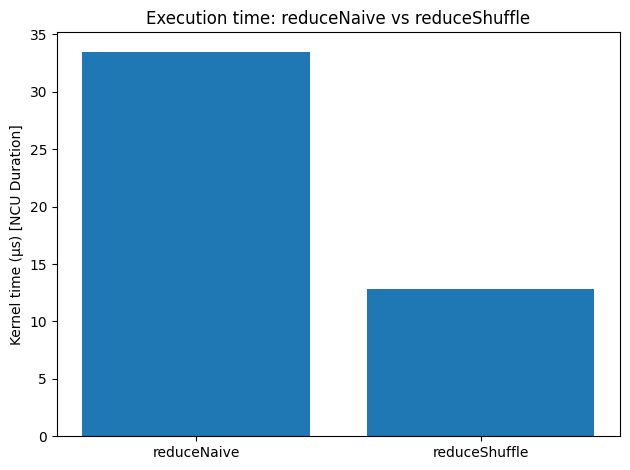

In [6]:
plt.figure()
plt.bar(kernels, duration_us)
plt.ylabel("Kernel time (µs) [NCU Duration]")
plt.title("Execution time: reduceNaive vs reduceShuffle")
plt.tight_layout()
plt.show()

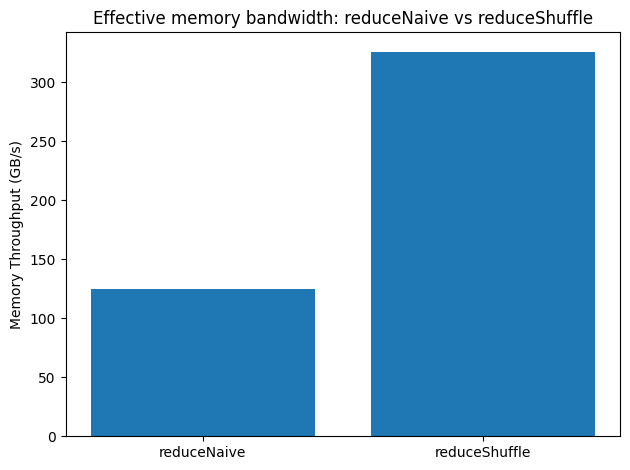

In [7]:
plt.figure()
plt.bar(kernels, mem_bw_gbs)
plt.ylabel("Memory Throughput (GB/s)")
plt.title("Effective memory bandwidth: reduceNaive vs reduceShuffle")
plt.tight_layout()
plt.show()

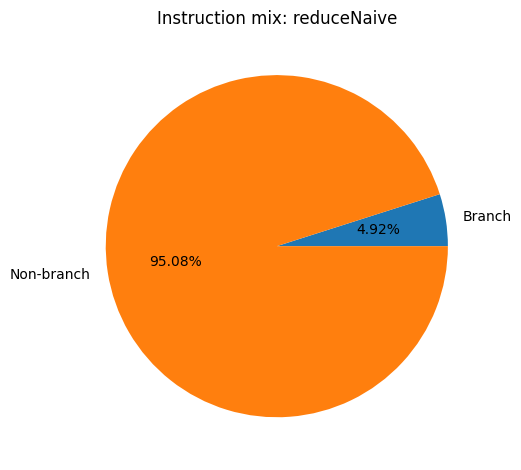

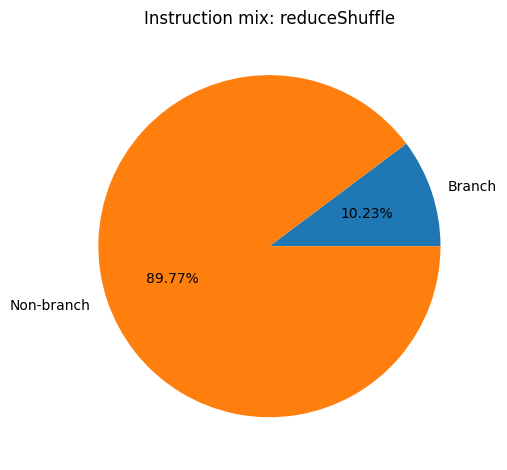

In [8]:
for k, br, nbr in zip(kernels, inst_branch, inst_nonbranch):
    plt.figure()
    plt.pie([br, nbr], labels=["Branch", "Non-branch"], autopct="%.2f%%")
    plt.title(f"Instruction mix: {k}")
    plt.tight_layout()
    plt.show()

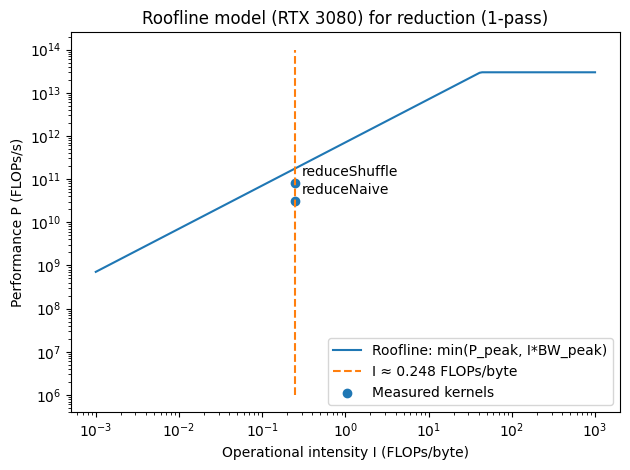

In [9]:
P_peak = 29.8e12          # FLOPs/s (FP32 peak) ~29.8 TFLOPS
BW_peak = 707.9e9         # bytes/s  (707.9 GB/s)

# Оценка FLOPs и bytes для одной редукции (1 проход)
N = 1 << 20
blockSize = 256
gridSize = (N + blockSize - 1) // blockSize

flops = (blockSize - 1) * gridSize                 # 255 сложений на блок
bytes = N * 4 + gridSize * 4                        # чтение N float + запись gridSize

I = flops / bytes                                   # FLOPs/byte

# Измеренная производительность по времени ядра
P_measured = flops / (duration_us * 1e-6)           # FLOPs/s

I_vals = np.logspace(-3, 3, 200)
P_roof = np.minimum(P_peak, I_vals * BW_peak)

plt.figure()
plt.loglog(I_vals, P_roof, label="Roofline: min(P_peak, I*BW_peak)")
plt.loglog([I, I], [1e6, 1e14], linestyle="--", label=f"I ≈ {I:.3f} FLOPs/byte")

plt.scatter([I, I], P_measured, label="Measured kernels")
for k, p in zip(kernels, P_measured):
    plt.annotate(k, (I, p), textcoords="offset points", xytext=(5, 5))

plt.xlabel("Operational intensity I (FLOPs/byte)")
plt.ylabel("Performance P (FLOPs/s)")
plt.title("Roofline model (RTX 3080) for reduction (1-pass)")
plt.legend()
plt.tight_layout()
plt.show()

# Vector Add

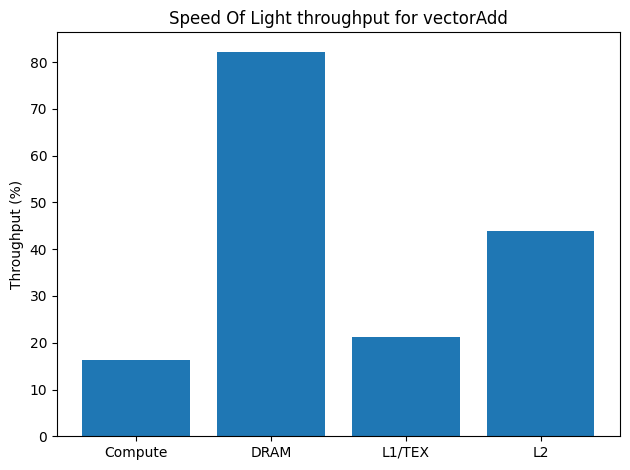

In [2]:
labels = ["Compute", "DRAM", "L1/TEX", "L2"]
throughput_pct = [16.24, 82.27, 21.17, 43.82]

plt.figure()
plt.bar(labels, throughput_pct)
plt.ylabel("Throughput (%)")
plt.title("Speed Of Light throughput for vectorAdd")
plt.tight_layout()
plt.show()

In [4]:
import numpy as np

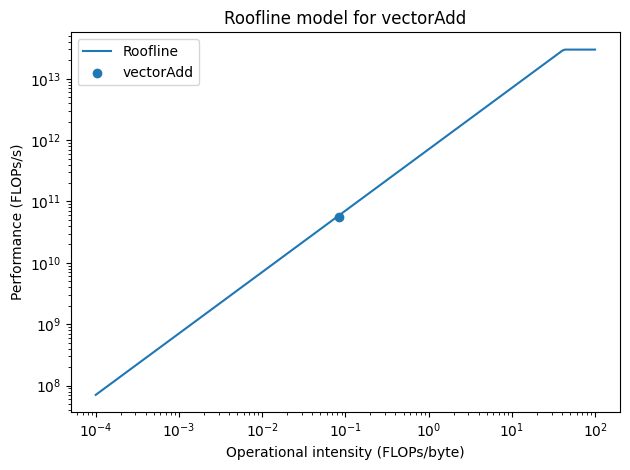

In [5]:
P_peak = 29.8e12      # FP32 peak FLOPs/s
BW_peak = 707.9e9     # peak bandwidth (bytes/s)

# vector add: 1 FLOP per element
N = 1 << 20
flops = N
bytes = N * 12        # 2 reads + 1 write (float)

I = flops / bytes     # FLOPs / byte
P_measured = flops / (18.82e-6)

I_vals = np.logspace(-4, 2, 200)
P_roof = np.minimum(P_peak, I_vals * BW_peak)

plt.figure()
plt.loglog(I_vals, P_roof, label="Roofline")
plt.scatter(I, P_measured, label="vectorAdd")
plt.xlabel("Operational intensity (FLOPs/byte)")
plt.ylabel("Performance (FLOPs/s)")
plt.title("Roofline model for vectorAdd")
plt.legend()
plt.tight_layout()
plt.show()